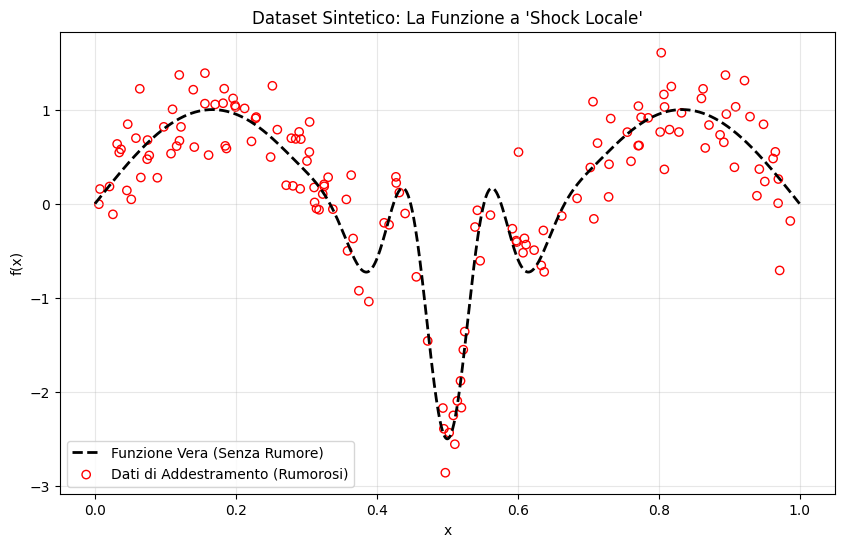

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definizione della funzione vera (Ground Truth)
def shock_function(x):
    base_wave = np.sin(3 * np.pi * x)
    shock_wave = 1.5 * np.exp(-100 * (x - 0.5)**2) * np.sin(15 * np.pi * x)
    return base_wave + shock_wave

# 2. Generazione del dominio denso per il test (La curva vera da indovinare)
x_true = np.linspace(0, 1, 1000)
y_true = shock_function(x_true)

# 3. Generazione del Dataset di Training (Punti sparsi + Rumore)
np.random.seed(42) # Per la riproducibilità
N_train = 150
x_train = np.sort(np.random.uniform(0, 1, N_train))

# Aggiungiamo rumore gaussiano (la varianza del rumore stimata dalla tua GCV!)
noise_level = 0.3 
y_train = shock_function(x_train) + np.random.normal(0, noise_level, N_train)

# 4. Visualizzazione
plt.figure(figsize=(10, 6))
plt.plot(x_true, y_true, 'k--', linewidth=2, label='Funzione Vera (Senza Rumore)')
plt.scatter(x_train, y_train, facecolors='none', edgecolors='red', label='Dati di Addestramento (Rumorosi)')
plt.title("Dataset Sintetico: La Funzione a 'Shock Locale'")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

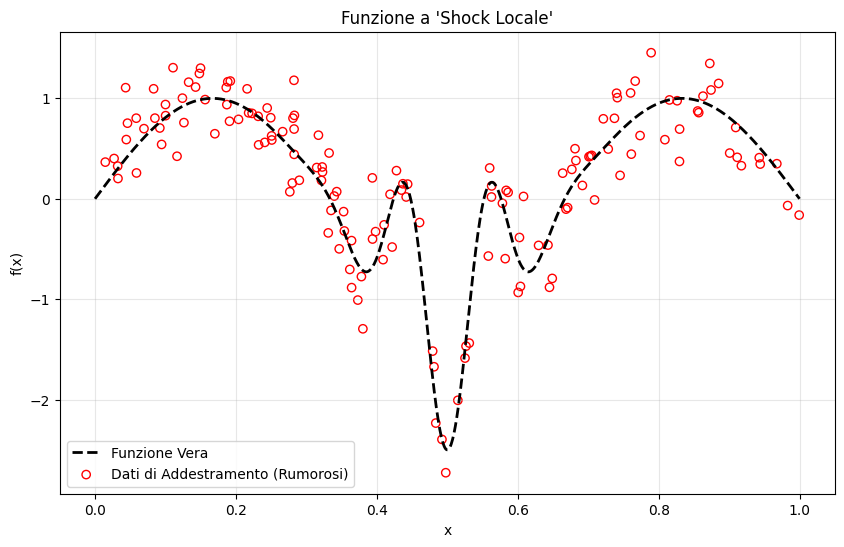

In [53]:
# Cella 2: Generazione del Dataset "Shock Locale"

# 1. Definizione della funzione vera (Ground Truth)
def shock_function(x):
    base_wave = np.sin(3 * np.pi * x)
    shock_wave = 1.5 * np.exp(-100 * (x - 0.5)**2) * np.sin(15 * np.pi * x)
    return base_wave + shock_wave

# 2. Dominio continuo per il test (la curva perfetta che il modello non conosce)
x_true = np.linspace(0, 1, 1000)
y_true = shock_function(x_true)

# 3. Generazione del Dataset di Training (i dati che daremo in pasto alla rete)
np.random.seed(41) # Fissiamo il seme per avere sempre gli stessi numeri casuali
N_train = 150
x_train = np.sort(np.random.uniform(0, 1, N_train))

# Aggiungiamo il rumore gaussiano (simula l'errore di misurazione)
noise_level = 0.3
y_train = shock_function(x_train) + np.random.normal(0, noise_level, N_train)

# 4. Disegniamo il grafico
plt.figure(figsize=(10, 6))
plt.plot(x_true, y_true, 'k--', linewidth=2, label='Funzione Vera')
plt.scatter(x_train, y_train, facecolors='none', edgecolors='red', label='Dati di Addestramento (Rumorosi)')
plt.title("Funzione a 'Shock Locale'")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

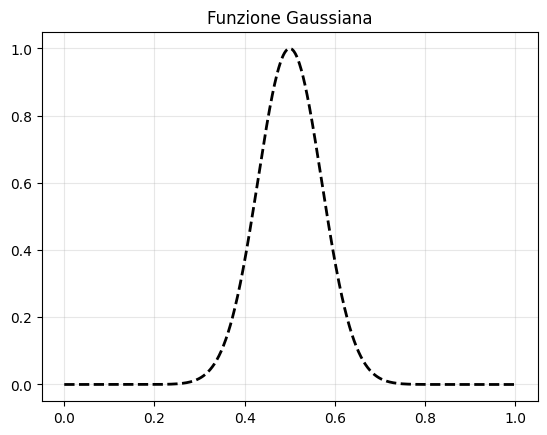

In [54]:
#definisco le funzioni a base radiale Gaussiane:
def gaussiane_rbf(x,c,r):
    phi = np.exp(-((x-c)**2)/(r**2))
    return phi

c = 0.5
r = 0.1
y_gauss = gaussiane_rbf(x_true,c,r)
plt.plot(x_true,y_gauss,'k--', linewidth=2)
plt.title("Funzione Gaussiana")
plt.grid(True, alpha = 0.3)
plt.show()

In [55]:
# Creo la matrice H di design
centri = x_train
H = np.zeros((len(x_train),len(centri)))
for j in range(len(centri)):
    H[:,j] = gaussiane_rbf(x_train,centri[j],r)
print(H.shape)

(150, 150)


In [56]:
# Noto che ho usato 150 centri per 150 punti, quindi m = p con lambda di regolarizzazione =0
# dovrei aspettarmi quindi matrice H mal condizionata, calcolo i pesi w
w = np.linalg.inv(H.T @ H) @ H.T @ y_train
print(w)

[-2.27676831e+13  3.28419004e+14  9.75340855e+14 -1.53179857e+15
 -7.37487073e+14  1.74623074e+15 -9.84822746e+14  5.84465796e+14
  7.76245225e+14 -2.27376676e+15  6.86748983e+14  1.53828235e+15
 -1.56198898e+15  1.34286234e+15 -7.37828883e+14 -6.69818390e+14
  9.81387179e+14  3.61038707e+14 -1.30185143e+15 -7.71135398e+14
  1.26884242e+15 -6.42235297e+12  1.20706982e+15 -9.21167897e+14
 -6.75577581e+13 -5.10356059e+14  3.25146004e+14 -2.10280130e+14
  6.42062965e+14  1.00922784e+14 -8.90807648e+14  9.59070075e+14
 -7.41397170e+14 -4.04574140e+14  6.28445004e+14 -8.01610599e+14
  2.69656516e+14  1.74712049e+14  7.40971344e+14 -6.82120126e+14
  2.76166426e+14  9.37667236e+13 -3.14302236e+14 -4.58843963e+14
  2.43375275e+14  4.31403514e+14 -3.53698118e+14  7.39246856e+13
  9.12664796e+14 -4.29898695e+14 -2.68948736e+14 -7.07059147e+14
  7.37094519e+14  6.68704122e+13 -1.06210196e+14  1.03370443e+14
 -3.95004132e+14  4.20420462e+13  2.71692751e+14  6.78322553e+14
 -8.82846504e+14  3.69153

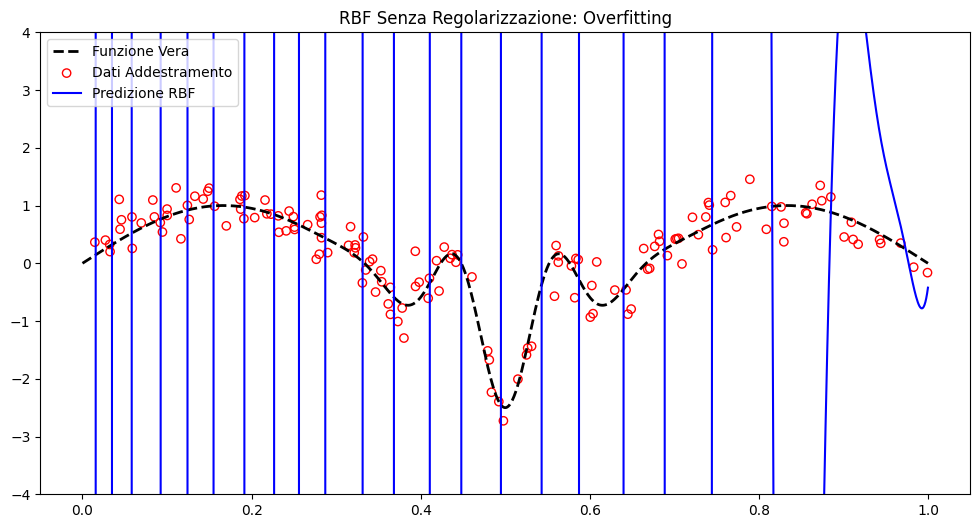

In [57]:
# 3. Costruiamo la H di test (1000 x 150) per fare le previsioni sulla curva continua
H_test = np.zeros((len(x_true), len(centri)))
for j in range(len(centri)):
    H_test[:, j] = gaussiane_rbf(x_true, centri[j], r) # Usiamo x_true qui!

y_pred = H_test @ w

plt.figure(figsize=(12, 6))
plt.plot(x_true, y_true, 'k--', linewidth=2, label='Funzione Vera')
plt.scatter(x_train, y_train, facecolors='none', edgecolors='red', label='Dati Addestramento')
plt.plot(x_true, y_pred, 'b-', linewidth=1.5, label='Predizione RBF')

# Mettiamo un limite all'asse Y, altrimenti le oscillazioni 
# dell'overfitting "strapperanno" il grafico!
plt.ylim([-4, 4]) 

plt.title("RBF Senza Regolarizzazione: Overfitting")
plt.legend()
plt.show()

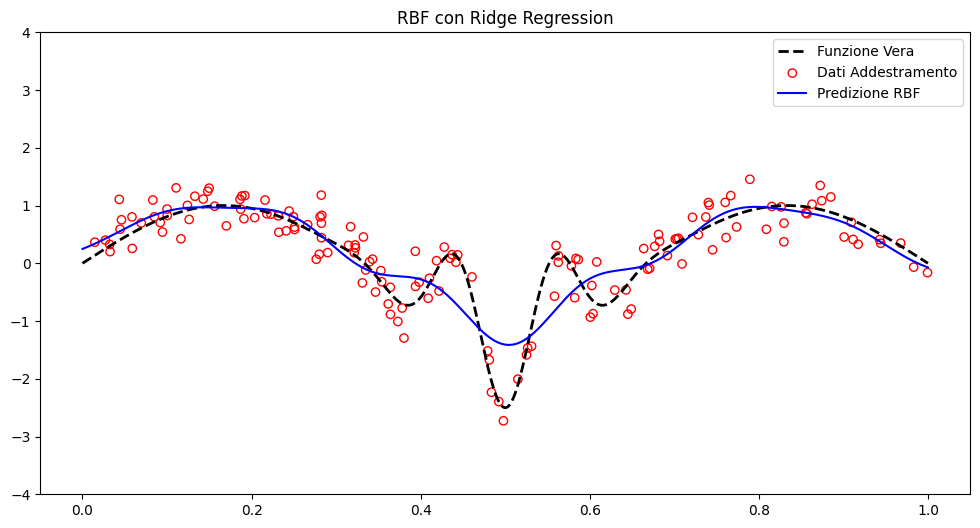

In [58]:
# passiamo quindi alla ridge regression
lam = 0.5
I = np.eye(len(centri))
H = np.zeros((len(x_train), len(centri)))
for j in range(len(centri)):
    H[:, j] = gaussiane_rbf(x_train, centri[j], r)  # <-- Corretto con la virgola!

# 2. Calcoliamo i pesi (il modello impara)
w = np.linalg.inv(H.T @ H+lam*I) @ H.T @ y_train

# 3. Costruiamo la H di test (1000 x 150) per fare le previsioni sulla curva continua
H_test = np.zeros((len(x_true), len(centri)))
for j in range(len(centri)):
    H_test[:, j] = gaussiane_rbf(x_true, centri[j], r) # Usiamo x_true qui!

# 4. Calcoliamo le predizioni per il grafico
y_pred = H_test @ w  # Ora y_pred avrà 1000 elementi, proprio come x_true!

# 5. Disegniamo il disastro
plt.figure(figsize=(12, 6))
plt.plot(x_true, y_true, 'k--', linewidth=2, label='Funzione Vera')
plt.scatter(x_train, y_train, facecolors='none', edgecolors='red', label='Dati Addestramento')
plt.plot(x_true, y_pred, 'b-', linewidth=1.5, label='Predizione RBF')

plt.ylim([-4, 4]) 
plt.title("RBF con Ridge Regression")
plt.legend()
plt.show()

Calcolo della GCV in corso...
Il lambda ottimale trovato è: 0.0001
Gradi di libertà effettivi impiegati (gamma): 130.8 su 150 disponibili.


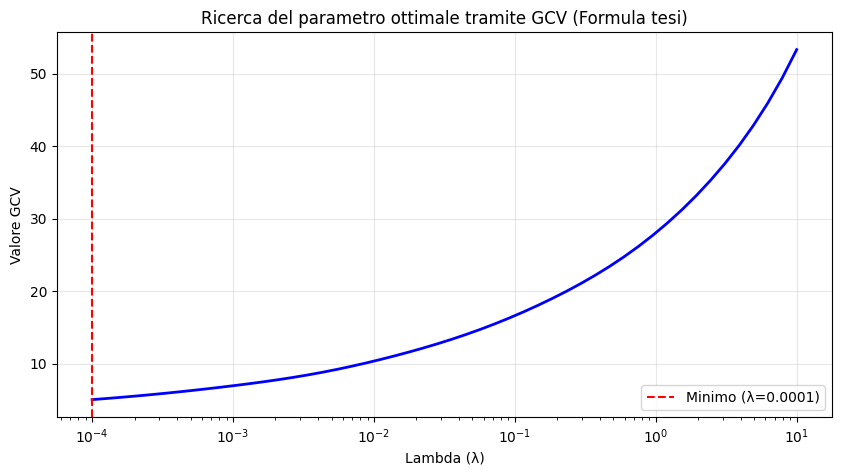

In [59]:
#utilizzo ora la GCV e poi confronto con Forward regression
# Ricerca del lambda ottimale tramite GCV

lambdas = np.logspace(-4, 1, 50)
gcv_scores = []
gammas = [] # Salviamo anche i gradi di libertà per curiosità
p = len(y_train) # Numero di dati (150)
I = np.eye(len(centri)) 

print("Calcolo della GCV in corso...")

for lam in lambdas:
    # A. Inversa della matrice regolarizzata
    inv_matrix = np.linalg.inv(H.T @ H + lam * I)
    
    # B. Calcolo dei pesi
    w_lam = inv_matrix @ H.T @ y_train
    
    # C. Calcolo dell'errore (S)
    y_pred_train = H @ w_lam
    S = np.sum((y_train - y_pred_train)**2) # Questa è la tua S
    
    # D. Matrice di proiezione e sua traccia
    P = H @ inv_matrix @ H.T
    traccia_P = np.trace(P)
    
    # I gradi di libertà impiegati (gamma) secondo la tua tesi: p - tr(P)
    gamma = p - traccia_P
    gammas.append(gamma)
    
    # E. La TUA formula finale della GCV: (p * S) / (p - gamma)^2
    # Che equivale a (p * S) / (traccia_P)^2
    gcv = (p * S) / (traccia_P**2)
    gcv_scores.append(gcv)

# 2. Troviamo il lambda vincente
indice_min = np.argmin(gcv_scores)
best_lam = lambdas[indice_min]
best_gamma = gammas[indice_min]

print(f"Il lambda ottimale trovato è: {best_lam:.4f}")
print(f"Gradi di libertà effettivi impiegati (gamma): {best_gamma:.1f} su {p} disponibili.")

# 3. Disegniamo la curva
plt.figure(figsize=(10, 5))
plt.plot(lambdas, gcv_scores, 'b-', linewidth=2)
plt.axvline(best_lam, color='r', linestyle='--', label=f'Minimo (λ={best_lam:.4f})')
plt.xscale('log') 
plt.title('Ricerca del parametro ottimale tramite GCV (Formula tesi)')
plt.xlabel('Lambda (λ)')
plt.ylabel('Valore GCV')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [60]:
# Cella 8: Algoritmo Forward Selection guidato dalla GCV

max_centri = 50 # Limite massimo di sicurezza
centri_selezionati = []
indici_rimanenti = list(range(len(x_train)))
storia_gcv = []
miglior_gcv = float('inf')
p = len(x_train)

print("Inizio ricerca dei centri ottimali...\n")

for step in range(max_centri):
    miglior_candidato_idx = -1
    min_errore_step = float('inf')
    
    # 1. ESPLORAZIONE: Proviamo ad aggiungere temporaneamente ogni centro rimasto
    for idx in indici_rimanenti:
        candidato = x_train[idx]
        centri_temporanei = centri_selezionati + [candidato]
        
        # Costruiamo la matrice H per questo set temporaneo
        H_temp = np.zeros((p, len(centri_temporanei)))
        for j, c in enumerate(centri_temporanei):
            H_temp[:, j] = gaussiane_rbf(x_train, c, r)
            
        # Calcoliamo i pesi (Usiamo la pseudoinversa pinv per stabilità numerica!)
        w_temp = np.linalg.pinv(H_temp) @ y_train
        y_pred_temp = H_temp @ w_temp
        
        # Calcoliamo l'errore (SSE)
        sse_temp = np.sum((y_train - y_pred_temp)**2)
        
        # Se questo candidato migliora l'errore più degli altri, lo salviamo come "vincitore"
        if sse_temp < min_errore_step:
            min_errore_step = sse_temp
            miglior_candidato_idx = idx
            
    # 2. AGGIORNAMENTO: Aggiungiamo il vincitore alla lista ufficiale
    nuovo_centro = x_train[miglior_candidato_idx]
    centri_selezionati.append(nuovo_centro)
    indici_rimanenti.remove(miglior_candidato_idx)
    
    # 3. VALUTAZIONE GCV: Calcoliamo la GCV ufficiale per il nuovo gruppo di centri
    H_ufficiale = np.zeros((p, len(centri_selezionati)))
    for j, c in enumerate(centri_selezionati):
        H_ufficiale[:, j] = gaussiane_rbf(x_train, c, r)
        
    H_inv = np.linalg.pinv(H_ufficiale) 
    w_ufficiale = H_inv @ y_train
    y_pred_ufficiale = H_ufficiale @ w_ufficiale
    
    S = np.sum((y_train - y_pred_ufficiale)**2)
    P = H_ufficiale @ H_inv
    traccia_P = np.trace(P)
    
    # Calcolo GCV (Formula della tua tesi)
    gcv = (p * S) / (traccia_P**2)
    storia_gcv.append(gcv)
    
    print(f"Step {step+1:02d}: Aggiunto centro in x={nuovo_centro:.3f} | GCV={gcv:.4f}")
    
    # 4. CONDIZIONE DI ARRESTO (Il cuore del Capitolo 6)
    # Se la GCV scende, continuiamo. Se sale, stiamo facendo overfitting e ci fermiamo!
    if step > 2 and gcv > miglior_gcv * 1.05: # 5% di tolleranza per le micro-oscillazioni
        print("\n[!] La GCV ha iniziato a salire. OVERFITTING RILEVATO.")
        print("[!] L'algoritmo si ferma e scarta l'ultimo centro.")
        centri_selezionati.pop() # Scartiamo l'ultimo centro che ha fatto danni
        break
    else:
        if gcv < miglior_gcv:
            miglior_gcv = gcv

print(f"\nSelezione completata! Centri ottimali selezionati: {len(centri_selezionati)} su 150.")

Inizio ricerca dei centri ottimali...

Step 01: Aggiunto centro in x=0.156 | GCV=10736.7288
Step 02: Aggiunto centro in x=0.498 | GCV=1820.0953
Step 03: Aggiunto centro in x=0.815 | GCV=515.2730
Step 04: Aggiunto centro in x=0.251 | GCV=283.7856
Step 05: Aggiunto centro in x=0.033 | GCV=177.0014
Step 06: Aggiunto centro in x=0.290 | GCV=122.1839
Step 07: Aggiunto centro in x=0.428 | GCV=88.3564
Step 08: Aggiunto centro in x=0.277 | GCV=65.4092
Step 09: Aggiunto centro in x=0.492 | GCV=46.8090
Step 10: Aggiunto centro in x=0.315 | GCV=34.0085
Step 11: Aggiunto centro in x=0.558 | GCV=23.7900
Step 12: Aggiunto centro in x=0.249 | GCV=18.0072
Step 13: Aggiunto centro in x=0.630 | GCV=12.6297
Step 14: Aggiunto centro in x=0.283 | GCV=10.0066
Step 15: Aggiunto centro in x=0.809 | GCV=7.8864
Step 16: Aggiunto centro in x=0.116 | GCV=6.7479
Step 17: Aggiunto centro in x=0.601 | GCV=5.8836
Step 18: Aggiunto centro in x=0.280 | GCV=5.1964
Step 19: Aggiunto centro in x=0.709 | GCV=4.5583
Step 20

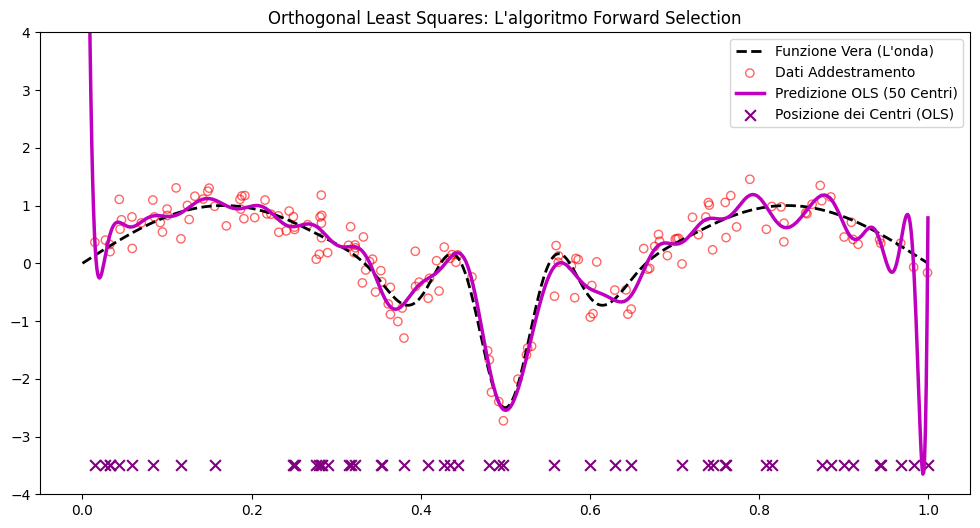

In [61]:
# Cella 9: Visualizzazione dei risultati OLS (Forward Selection)

# 1. Costruiamo la matrice di test solo con i 50 centri selezionati
H_test_ols = np.zeros((len(x_true), len(centri_selezionati)))
for j, c in enumerate(centri_selezionati):
    H_test_ols[:, j] = gaussiane_rbf(x_true, c, r)

# 2. Calcoliamo la predizione finale
y_pred_ols = H_test_ols @ w_ufficiale

# 3. Disegniamo il capolavoro
plt.figure(figsize=(12, 6))
plt.plot(x_true, y_true, 'k--', linewidth=2, label='Funzione Vera (L\'onda)')
plt.scatter(x_train, y_train, facecolors='none', edgecolors='red', alpha=0.6, label='Dati Addestramento')
plt.plot(x_true, y_pred_ols, 'm-', linewidth=2.5, label='Predizione OLS (50 Centri)')

# TRUCCO GRAFICO: Disegniamo delle "X" sul fondo del grafico per vedere dove sono i centri
y_bottom = np.full(len(centri_selezionati), -3.5)
plt.scatter(centri_selezionati, y_bottom, color='purple', marker='x', s=60, label='Posizione dei Centri (OLS)')

plt.title("Orthogonal Least Squares: L'algoritmo Forward Selection")
plt.ylim([-4, 4])
plt.legend()
plt.show()

In [68]:
# Cella 10: Algoritmo ROLS (Regularized Orthogonal Least Squares)

max_centri = 50
centri_rols = []
indici_rimanenti_rols = list(range(len(x_train)))
storia_gcv_rols = []
miglior_gcv_rols = float('inf')
p = len(x_train)

# Scegliamo un piccolo lambda per stabilizzare la rete ed evitare l'esplosione ai bordi
lam_rols = 1e-5

print("Inizio ROLS (Forward Selection con Regolarizzazione)...\n")

for step in range(max_centri):
    miglior_candidato_idx = -1
    min_errore_step = float('inf')
    
    # 1. ESPLORAZIONE: Valutiamo i candidati usando la matrice REGOLARIZZATA
    for idx in indici_rimanenti_rols:
        candidato = x_train[idx]
        centri_temp = centri_rols + [candidato]
        
        H_temp = np.zeros((p, len(centri_temp)))
        for j, c in enumerate(centri_temp):
            H_temp[:, j] = gaussiane_rbf(x_train, c, r)
            
        I_temp = np.eye(len(centri_temp))
        
        # LA MAGIA È QUI: Inseriamo lambda * I direttamente nella selezione!
        inv_matrix_temp = np.linalg.inv(H_temp.T @ H_temp + lam_rols * I_temp)
        w_temp = inv_matrix_temp @ H_temp.T @ y_train
        y_pred_temp = H_temp @ w_temp
        
        sse_temp = np.sum((y_train - y_pred_temp)**2)
        
        if sse_temp < min_errore_step:
            min_errore_step = sse_temp
            miglior_candidato_idx = idx
            
    # 2. AGGIORNAMENTO
    nuovo_centro = x_train[miglior_candidato_idx]
    centri_rols.append(nuovo_centro)
    indici_rimanenti_rols.remove(miglior_candidato_idx)
    
    # 3. VALUTAZIONE GCV
    H_uff = np.zeros((p, len(centri_rols)))
    for j, c in enumerate(centri_rols):
        H_uff[:, j] = gaussiane_rbf(x_train, c, r)
        
    I_uff = np.eye(len(centri_rols))
    inv_matrix_uff = np.linalg.inv(H_uff.T @ H_uff + lam_rols * I_uff)
    w_ufficiale_rols = inv_matrix_uff @ H_uff.T @ y_train
    y_pred_uff = H_uff @ w_ufficiale_rols
    
    S = np.sum((y_train - y_pred_uff)**2)
    P = H_uff @ inv_matrix_uff @ H_uff.T
    traccia_P = np.trace(P)
    
    gcv = (p * S) / (traccia_P**2)
    storia_gcv_rols.append(gcv)
    
    print(f"Step {step+1:02d}: Aggiunto x={nuovo_centro:.3f} | GCV={gcv:.4f}")
    
    # 4. CONDIZIONE DI ARRESTO
    if step > 2 and gcv > miglior_gcv_rols * 1.02: # 2% di tolleranza
        print("\n[!] La GCV sale. Equilibrio perfetto raggiunto. Mi fermo.")
        centri_rols.pop() # Scartiamo l'ultimo che peggiora le cose
        break
    else:
        if gcv < miglior_gcv_rols:
            miglior_gcv_rols = gcv

print(f"\nSelezione completata! ROLS ha scelto {len(centri_rols)} centri ottimali.")

Inizio ROLS (Forward Selection con Regolarizzazione)...

Step 01: Aggiunto x=0.156 | GCV=10736.7393
Step 02: Aggiunto x=0.498 | GCV=1820.0973
Step 03: Aggiunto x=0.815 | GCV=515.2736
Step 04: Aggiunto x=0.251 | GCV=283.7860
Step 05: Aggiunto x=0.033 | GCV=177.0017
Step 06: Aggiunto x=0.290 | GCV=122.1847
Step 07: Aggiunto x=0.428 | GCV=88.3572
Step 08: Aggiunto x=0.277 | GCV=65.5731
Step 09: Aggiunto x=0.492 | GCV=47.0433
Step 10: Aggiunto x=0.340 | GCV=36.6071
Step 11: Aggiunto x=0.563 | GCV=26.5274
Step 12: Aggiunto x=0.362 | GCV=23.9069
Step 13: Aggiunto x=0.692 | GCV=18.9389
Step 14: Aggiunto x=0.515 | GCV=16.6839
Step 15: Aggiunto x=0.789 | GCV=12.7268
Step 16: Aggiunto x=0.133 | GCV=10.6307
Step 17: Aggiunto x=0.380 | GCV=10.1728
Step 18: Aggiunto x=0.999 | GCV=8.8045
Step 19: Aggiunto x=0.525 | GCV=8.6906
Step 20: Aggiunto x=0.709 | GCV=7.6866
Step 21: Aggiunto x=0.444 | GCV=7.5879
Step 22: Aggiunto x=0.857 | GCV=6.7353
Step 23: Aggiunto x=0.586 | GCV=6.4160
Step 24: Aggiunto x=

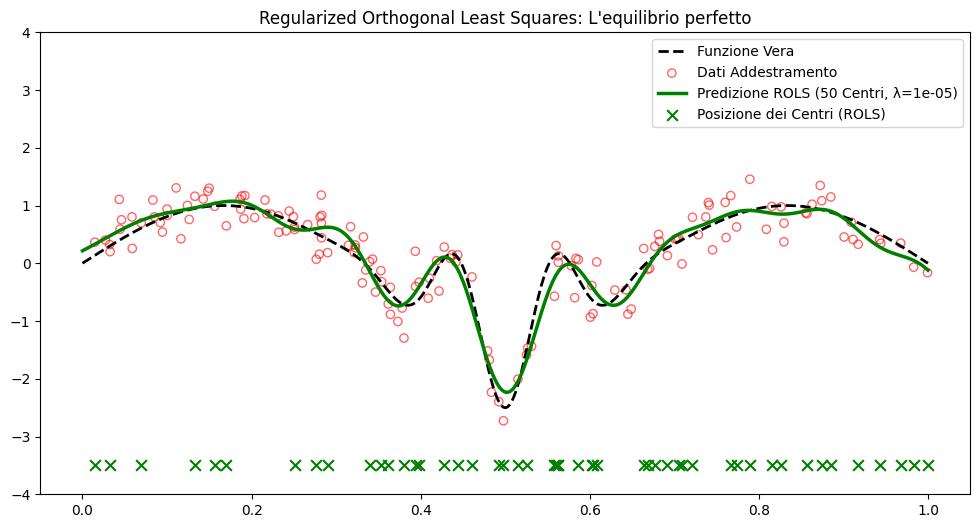

In [69]:
# Cella 11: Visualizzazione dei risultati definitivi (ROLS)

# 1. Costruiamo la matrice di test per la curva continua
H_test_rols = np.zeros((len(x_true), len(centri_rols)))
for j, c in enumerate(centri_rols):
    H_test_rols[:, j] = gaussiane_rbf(x_true, c, r)

# 2. Ricalcoliamo i pesi definitivi con i centri scelti e il nostro lambda
H_final = np.zeros((p, len(centri_rols)))
for j, c in enumerate(centri_rols):
    H_final[:, j] = gaussiane_rbf(x_train, c, r)
    
I_final = np.eye(len(centri_rols))
w_final = np.linalg.inv(H_final.T @ H_final + lam_rols * I_final) @ H_final.T @ y_train

y_pred_rols_grafico = H_test_rols @ w_final

# 3. Disegniamo l'ultimo grafico
plt.figure(figsize=(12, 6))
plt.plot(x_true, y_true, 'k--', linewidth=2, label='Funzione Vera')
plt.scatter(x_train, y_train, facecolors='none', edgecolors='red', alpha=0.6, label='Dati Addestramento')
plt.plot(x_true, y_pred_rols_grafico, 'g-', linewidth=2.5, label=f'Predizione ROLS ({len(centri_rols)} Centri, \u03BB={lam_rols})')

# Disegniamo le posizioni dei centri
y_bottom = np.full(len(centri_rols), -3.5)
plt.scatter(centri_rols, y_bottom, color='green', marker='x', s=60, label='Posizione dei Centri (ROLS)')

plt.title("Regularized Orthogonal Least Squares: L'equilibrio perfetto")
plt.ylim([-4, 4])
plt.legend()
plt.show()

Inizio addestramento della rete con PyTorch...
Epoca 1000/5000 | Loss (MSE): 0.0913
Epoca 2000/5000 | Loss (MSE): 0.0827
Epoca 3000/5000 | Loss (MSE): 0.0854
Epoca 4000/5000 | Loss (MSE): 0.0829
Epoca 5000/5000 | Loss (MSE): 0.0836
Addestramento completato!


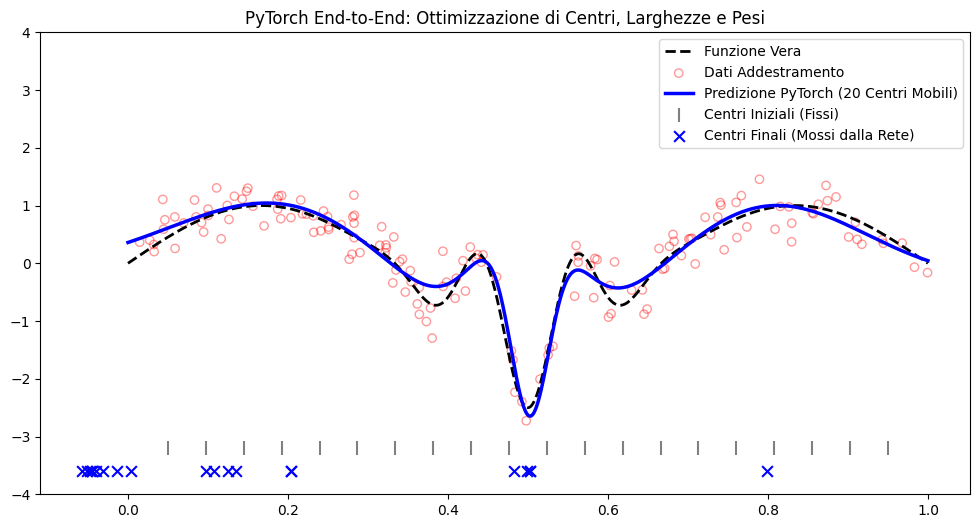

In [71]:
# Cella 12: Ottimizzazione Continua con PyTorch (Backpropagation)

import torch
import torch.nn as nn
import torch.optim as optim

# 1. Prepariamo i dati per PyTorch (convertiamo da NumPy a Tensori)
# Usiamo view(-1, 1) per trasformarli in vettori colonna
x_train_t = torch.tensor(x_train, dtype=torch.float32).view(-1, 1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
x_test_t = torch.tensor(x_true, dtype=torch.float32).view(-1, 1)

# 2. Definiamo l'architettura della Rete Neurale RBF
class RBFNetwork(nn.Module):
    def __init__(self, num_centers):
        super(RBFNetwork, self).__init__()
        
        # A. I Centri (c): Li inizializziamo equispaziati tra 0 e 1, ma liberi di muoversi
        self.centers = nn.Parameter(torch.linspace(0.05, 0.95, num_centers).unsqueeze(0))
        
        # B. Le Larghezze (sigma): Ottimizziamo il logaritmo per evitare che sigma diventi negativo
        # log(0.1) è circa -2.3 (partiamo con campane strette come prima)
        self.log_sigmas = nn.Parameter(torch.full((1, num_centers), -2.3))
        
        # C. I Pesi (w): Inizializzati casualmente
        self.weights = nn.Parameter(torch.randn(num_centers, 1) * 0.1)
        
    def forward(self, x):
        # x ha dimensione (N, 1), centers ha dimensione (1, M)
        # Sfruttiamo il broadcasting per calcolare tutte le distanze in un colpo solo
        distances_sq = (x - self.centers)**2 
        
        sigmas = torch.exp(self.log_sigmas)
        
        # phi(x) = exp( - (x-c)^2 / sigma^2 )
        phi = torch.exp(-distances_sq / (sigmas**2))
        
        # Moltiplichiamo per i pesi: H @ w
        return phi @ self.weights

# 3. Creiamo il modello: usiamo solo 20 centri! (Contro i 50 di ROLS e 150 di Ridge)
num_neuroni = 20
model = RBFNetwork(num_centers=num_neuroni)

# Salviamo la posizione iniziale dei centri per il grafico finale
centri_iniziali = model.centers.detach().numpy().flatten()

# 4. Configurazione del Training
optimizer = optim.Adam(model.parameters(), lr=0.02, weight_decay=1e-3) # Adam è ottimo per questo
criterion = nn.MSELoss() # La nostra S (Sum of Squared Errors) media

epochs = 5000
print("Inizio addestramento della rete con PyTorch...")

for epoch in range(epochs):
    optimizer.zero_grad()    # Resettiamo i gradienti
    y_pred = model(x_train_t) # Forward pass
    loss = criterion(y_pred, y_train_t) # Calcolo errore
    loss.backward()          # Backpropagation (calcolo delle derivate)
    optimizer.step()         # Aggiornamento di c, sigma e w
    
    if (epoch + 1) % 1000 == 0:
        print(f"Epoca {epoch+1:04d}/{epochs} | Loss (MSE): {loss.item():.4f}")

print("Addestramento completato!")

# 5. Estraiamo i risultati
with torch.no_grad(): # Spegniamo il calcolo dei gradienti
    y_pred_pytorch = model(x_test_t).numpy().flatten()
    centri_finali = model.centers.numpy().flatten()

# 6. Disegniamo il risultato
plt.figure(figsize=(12, 6))
plt.plot(x_true, y_true, 'k--', linewidth=2, label='Funzione Vera')
plt.scatter(x_train, y_train, facecolors='none', edgecolors='red', alpha=0.4, label='Dati Addestramento')
plt.plot(x_true, y_pred_pytorch, 'b-', linewidth=2.5, label=f'Predizione PyTorch ({num_neuroni} Centri Mobili)')

# Visualizziamo i centri iniziali e finali
y_bottom_init = np.full(num_neuroni, -3.2)
y_bottom_final = np.full(num_neuroni, -3.6)
plt.scatter(centri_iniziali, y_bottom_init, color='gray', marker='|', s=100, label='Centri Iniziali (Fissi)')
plt.scatter(centri_finali, y_bottom_final, color='blue', marker='x', s=60, label='Centri Finali (Mossi dalla Rete)')

plt.title("PyTorch End-to-End: Ottimizzazione di Centri, Larghezze e Pesi")
plt.ylim([-4, 4])
plt.legend()
plt.show()